# Scoped event-based analysis — Exorde stratified sample

This notebook analyses `stratified_sample_1M.csv` (platform-stratified sample from [Exorde/exorde-social-media-december-2024-week1](https://huggingface.co/datasets/Exorde/exorde-social-media-december-2024-week1)).

**Date range in source data:** 2024-12-01 to 2024-12-07 (UTC, as in the Hugging Face snapshot).

**Context:** Day-by-day real-world headlines for that week are listed in `notable-events.txt` (Gaza, Syria offensive, Romania election annulment, France/Barnier, etc.) — use for qualitative interpretation, not as ground truth for posts.

**Events (keyword-defined in `exorde_analysis.py`):** US politics, Gaza / Israel, Syria, Romania, Sri Lanka / NPP.

Core logic lives in `exorde_analysis.py` (aggregations, tests). Load the CSV with `pd.read_csv`, then `out = run_pipeline(df)`.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from exorde_analysis import (
    EVENTS,
    chi_square_emotion_platform,
    daily_entropy,
    daily_event_df,
    get_platform,
    hourly_event_df,
    long_format_day_language,
    long_format_day_platform,
    peak_day_share,
    reservoirs_to_long_df,
    run_pipeline,
    run_kruskal_for_event,
    run_pca_kmeans,
)

sns.set_theme(style="whitegrid")
CSV_PATH = Path("data/stratified_dates_platforms_1M.csv")

In [7]:
# ~1M rows — full load + aggregations can take a few minutes.
df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
df["platform"] = df["url"].map(get_platform) if "url" in df.columns else "missing"
_week_start = pd.Timestamp("2024-12-01", tz="UTC")
_dt = pd.to_datetime(df["date"], utc=True, errors="coerce")
df["day"] = (_dt.dt.floor("D") - _week_start).dt.days + 1
out = run_pipeline(df)

In [23]:
df["day"] = pd.to_datetime(df["date"]).dt.date
df["day"].value_counts().sort_index()

day
2024-12-01    142857
2024-12-02    142857
2024-12-03    142857
2024-12-04    142857
2024-12-05    142857
2024-12-06    142857
2024-12-07    142857
Name: count, dtype: int64

## 1. EDA — quality and marginal distributions

In [9]:
print("rows:", out["n_rows"])
print("missing sentiment:", out["sentiment_missing"], "missing url:", out["url_missing"])
print("approx duplicate rate (URL subsample):", round(out["dup_rate_url_subsample"], 4), "n=", out["url_subsample_size"])

top_theme = pd.Series(dict(out["theme_counts"].most_common(12)))
top_lang = pd.Series(dict(out["lang_counts"].most_common(12)))
top_plat = pd.Series(dict(out["platform_counts"].most_common(12)))
display(pd.DataFrame({"primary_theme": top_theme}), pd.DataFrame({"language": top_lang}), pd.DataFrame({"platform": top_plat}))

rows: 999999
missing sentiment: 0 missing url: 0
approx duplicate rate (URL subsample): 0.0 n= 80000


,primary_theme
Entertainment,207592
People,173220
Technology,105153
Politics,100464
Sports,80093
Environment,61558
Social,50102
Health,44651
Cryptocurrency,41702
Science,40344


,language
en,730979
es,68396
ja,55874
pt,47849
fr,14357
de,13658
ar,10302
id,9561
tr,7914
it,7408


,platform
x.com,675011
reddit.com,195274
bsky.app,99027
youtube.com,23918
boards.4channel.org,3157
jeuxvideo.com,826
forocoches.com,749
mastodon.social,538
news.ycombinator.com,434
old.reddit.com,42


### Data summary (Section 1 — tables, not plots)

These outputs are **tables**, not charts: **row count**, **missing** sentiment/URL counts, **approximate duplicate rate** on a URL subsample, and the **top 12** primary themes, languages, and **platform domains**. Marginal platform counts reflect the **stratified sample**, not global web share.


## 2. Global time series — daily volume and mean sentiment

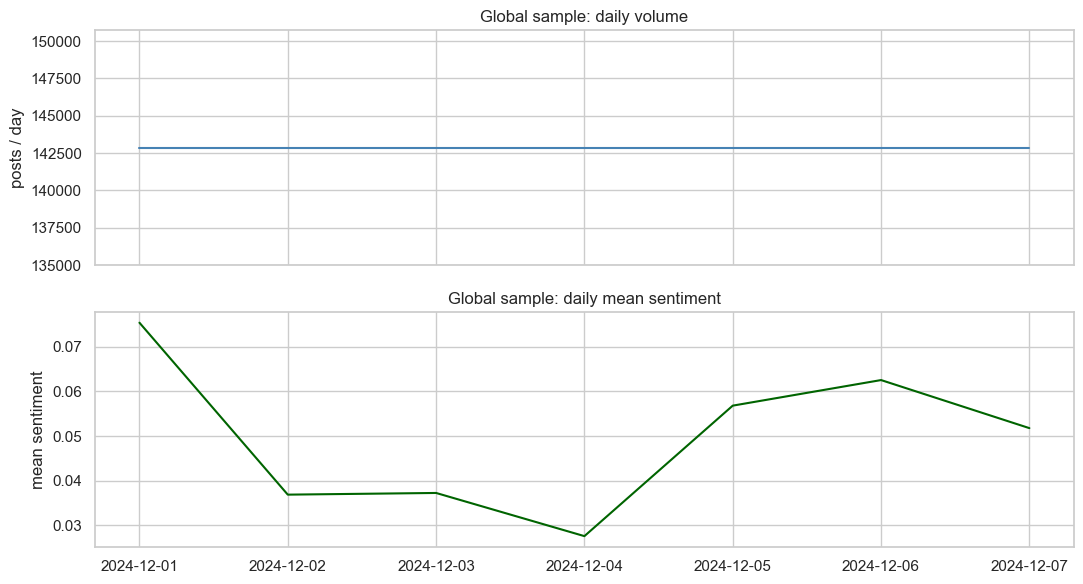

In [12]:
dg = out["daily_global"].copy()
dg["date"] = pd.to_datetime(dg["date"])

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(dg["date"], dg["n"], color="steelblue")
ax[0].set_ylabel("posts / day")
ax[0].set_title("Global sample: daily volume")
ax[1].plot(dg["date"], dg["mean_sentiment"], color="darkgreen")
ax[1].set_ylabel("mean sentiment")
ax[1].set_title("Global sample: daily mean sentiment")
plt.tight_layout()
plt.show()

### Figure — Global daily volume and mean sentiment

**Top:** Posts per **calendar day (UTC)** across the entire 1M analytical sample. **Bottom:** **Mean sentiment** (dataset scale) per day, averaged over all posts. Use this pair to see whether the week is **flat or uneven** overall; it does **not** isolate any keyword-defined event.


## 3. Event subsets — counts and concentration

Operational definitions: substring match on `english_keywords` + `original_text` (see `EVENTS` in `exorde_analysis.py`).

In [13]:
summary = []
for ev, spec in EVENTS.items():
    summary.append(
        {
            "event": ev,
            "label": spec["label"],
            "n_posts": out["event_n"][ev],
            "pct_sample": round(out["event_pct"][ev], 3),
            "peak_day_share": round(peak_day_share(out["ed_daily"], ev), 4),
            "daily_entropy": round(daily_entropy(out["ed_daily"], ev), 4),
        }
    )
ev_df = pd.DataFrame(summary)
display(ev_df)

,event,label,n_posts,pct_sample,peak_day_share,daily_entropy
0,us_politics,"US politics (post–US election, Dec 2024 week)",33188,3.319,0.2372,1.8948
1,syria,"Syria conflict (rebel offensive, Dec 2024)",4681,0.468,0.2320,1.9010
2,romania,Romania (election annulment / political crisis),433,0.043,0.3210,1.7752
3,sri_lanka,Sri Lanka / NPP,1065,0.107,0.2047,1.9092
4,gaza_israel,Gaza / Israel,6623,0.662,0.1887,1.9351


### Table — Event counts and concentration (Section 3)

**n_posts** / **pct_sample** refer to posts whose text matches that event’s **keyword list** in this sample. **peak_day_share** is the fraction of the event’s posts that fall on its single busiest day (values near 1 mean attention **clumped** on one day). **daily_entropy** measures how **spread out** daily volumes are across the week (higher ≈ more even spread).


## 4. Temporal dynamics and cross-platform spread

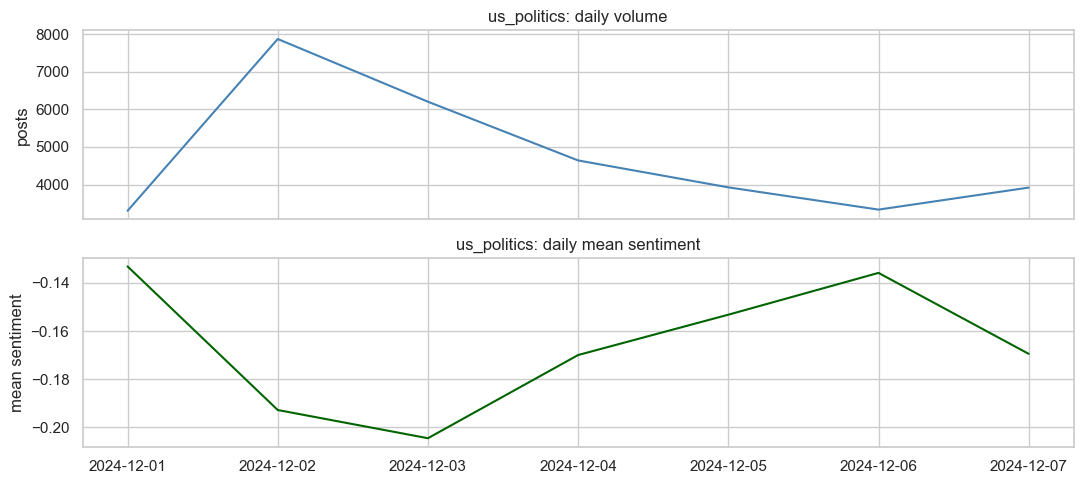

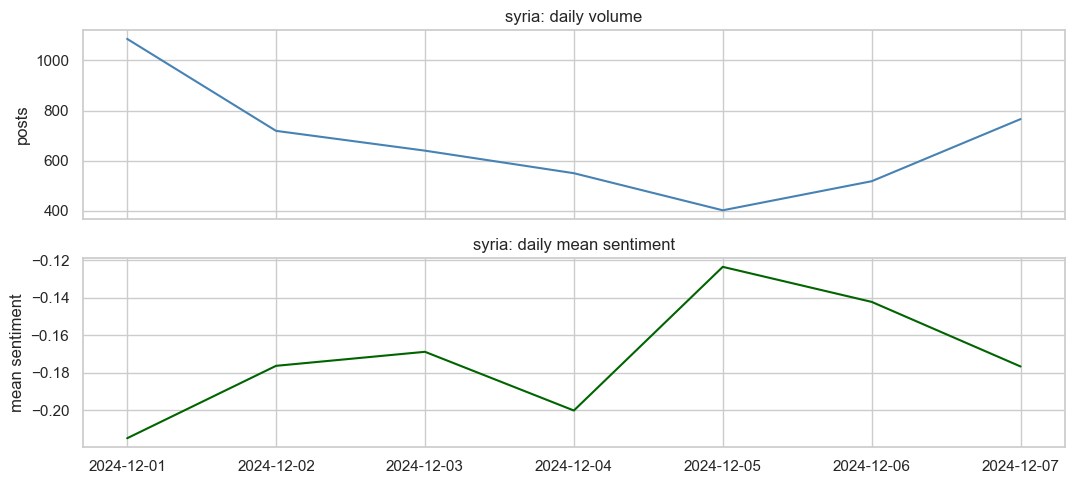

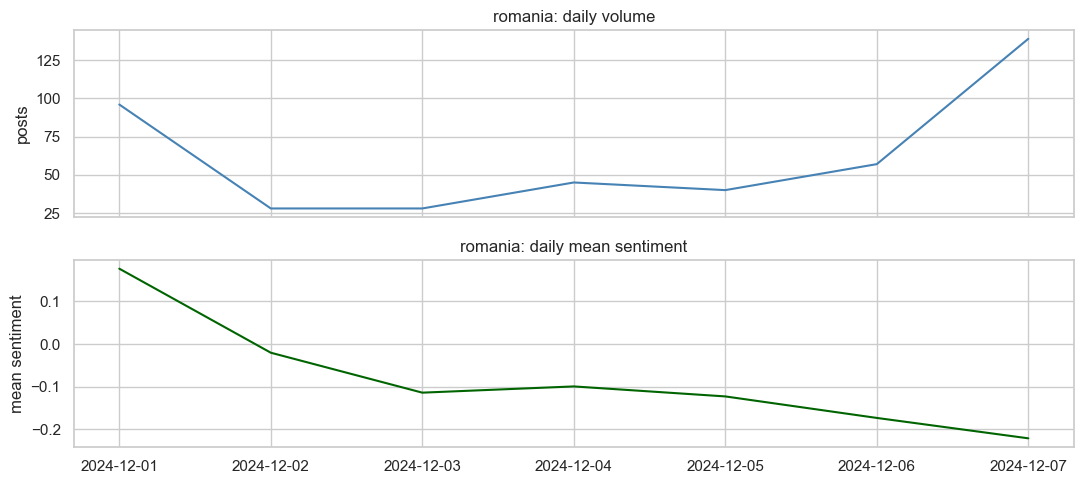

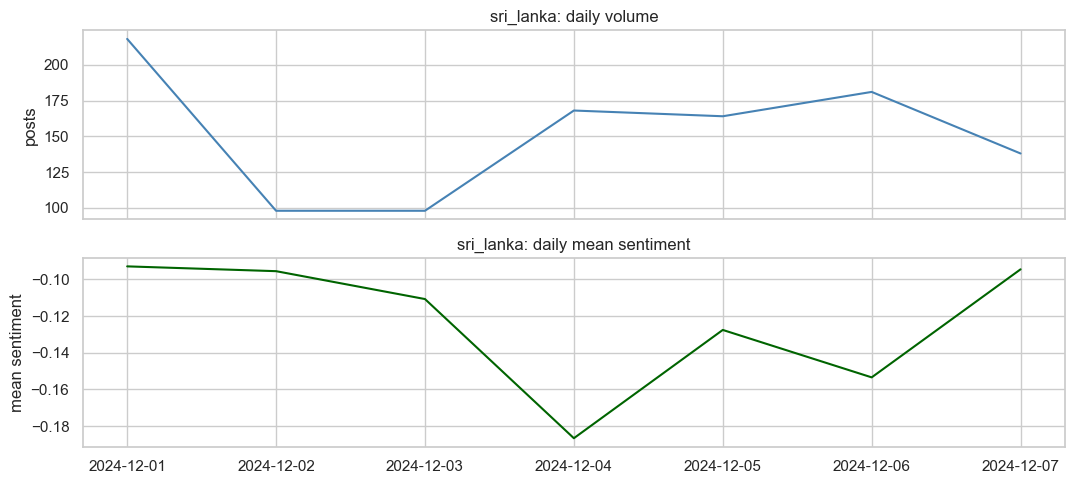

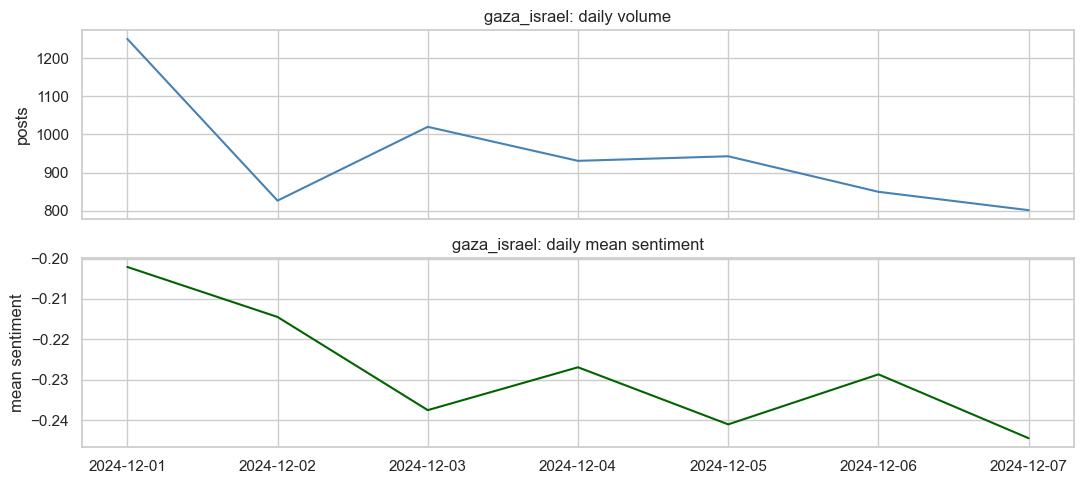

In [14]:
def plot_event_timeseries(ed_daily, event_name: str):
    dfe = daily_event_df(ed_daily, event_name)
    dfe["date"] = pd.to_datetime(dfe["date"])
    fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    ax[0].plot(dfe["date"], dfe["n"], color="steelblue")
    ax[0].set_ylabel("posts")
    ax[0].set_title(f"{event_name}: daily volume")
    ax[1].plot(dfe["date"], dfe["mean_sentiment"], color="darkgreen")
    ax[1].set_ylabel("mean sentiment")
    ax[1].set_title(f"{event_name}: daily mean sentiment")
    plt.tight_layout()
    plt.show()


for ev in EVENTS:
    plot_event_timeseries(out["ed_daily"], ev)

### Figures — Per-event daily volume and mean sentiment

For **each** keyword-defined event, the **upper** panel shows **daily post counts** in that event’s slice; the **lower** panel shows **daily mean sentiment** in the same slice. **Compare shapes** across events (spikes, plateaus); levels depend on **keyword breadth** and noise.


**Note:** If the CSV contains only a few distinct calendar dates (as in this stratified extract), daily lines look sparse. **Hourly** aggregates show intraday spread (UTC).

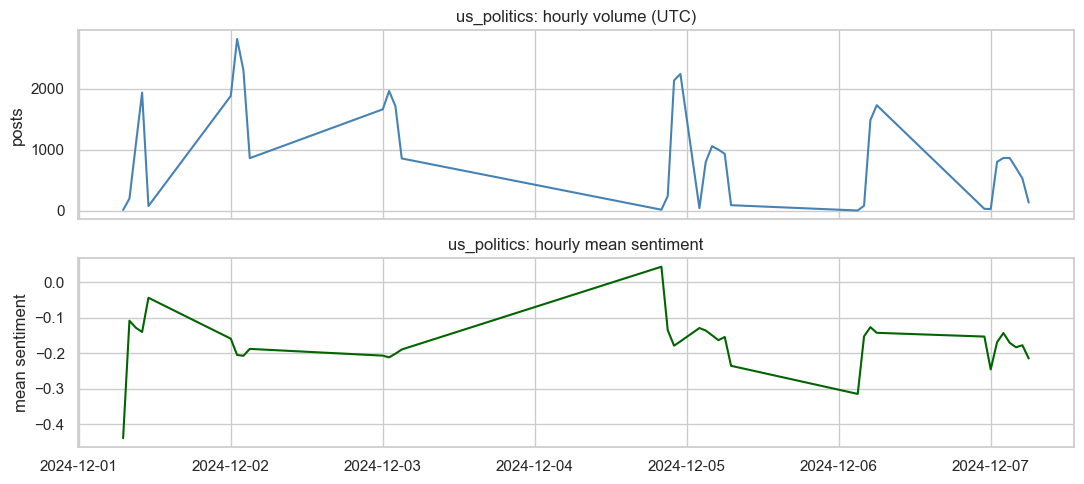

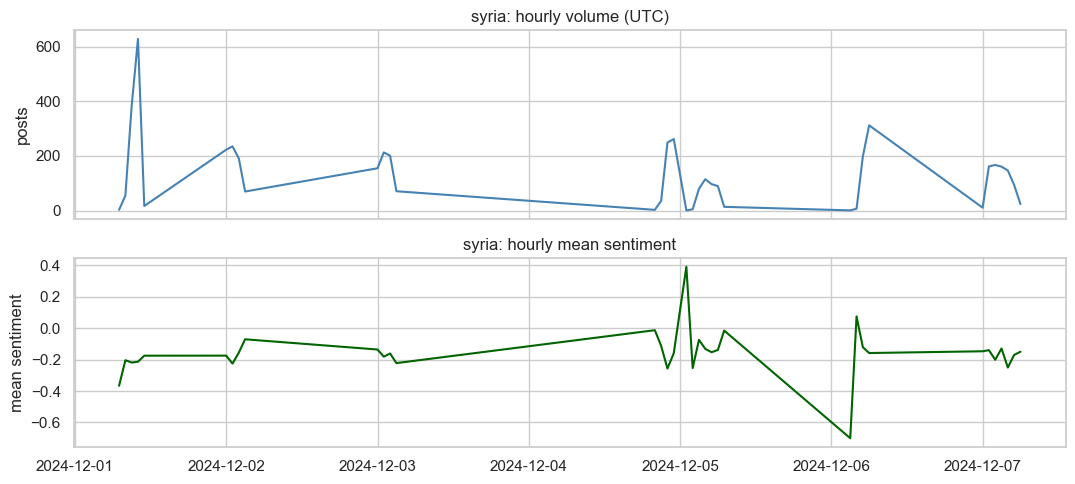

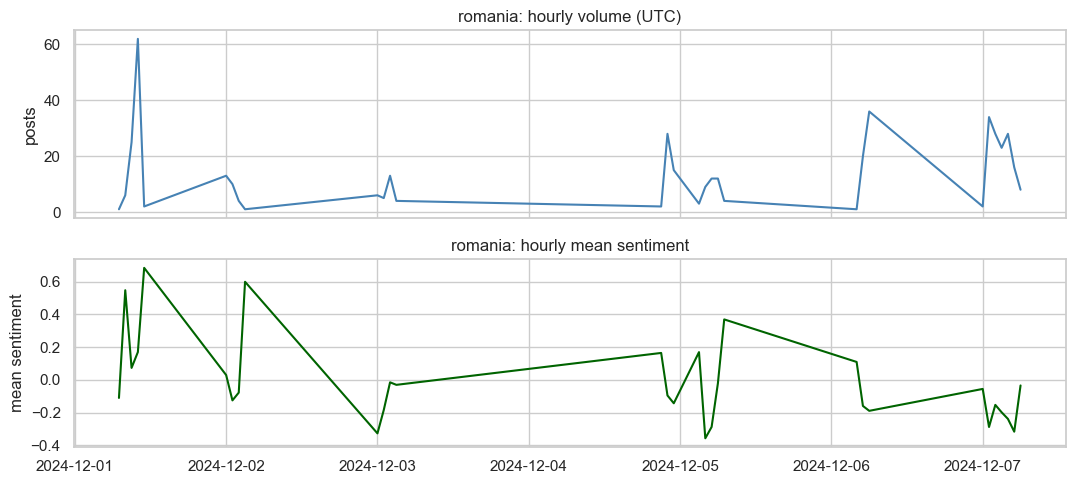

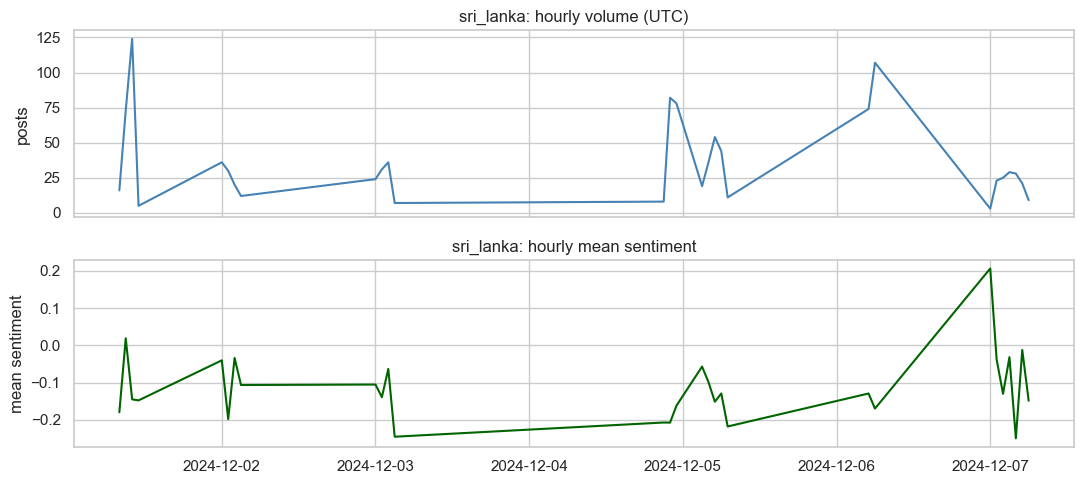

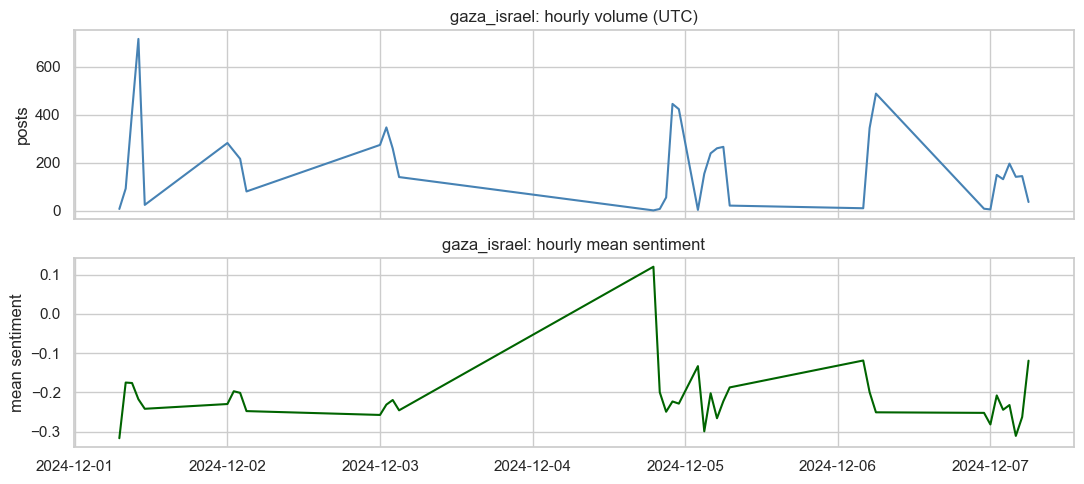

In [15]:
ed_hour = out["ed_hourly"]

for ev in EVENTS:
    hdf = hourly_event_df(ed_hour, ev)
    if hdf.empty or len(hdf) < 2:
        continue
    hdf["hour"] = pd.to_datetime(hdf["hour"])
    fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    ax[0].plot(hdf["hour"], hdf["n"], color="steelblue")
    ax[0].set_ylabel("posts")
    ax[0].set_title(f"{ev}: hourly volume (UTC)")
    ax[1].plot(hdf["hour"], hdf["mean_sentiment"], color="darkgreen")
    ax[1].set_ylabel("mean sentiment")
    ax[1].set_title(f"{ev}: hourly mean sentiment")
    plt.tight_layout()
    plt.show()

### Figures — Hourly volume and mean sentiment (UTC)

Same layout as the daily plots, but the x-axis is **UTC hour** (from the hourly aggregation). Useful when calendar-day coverage is **thin**; interpret timestamps as **UTC**, not local news time.


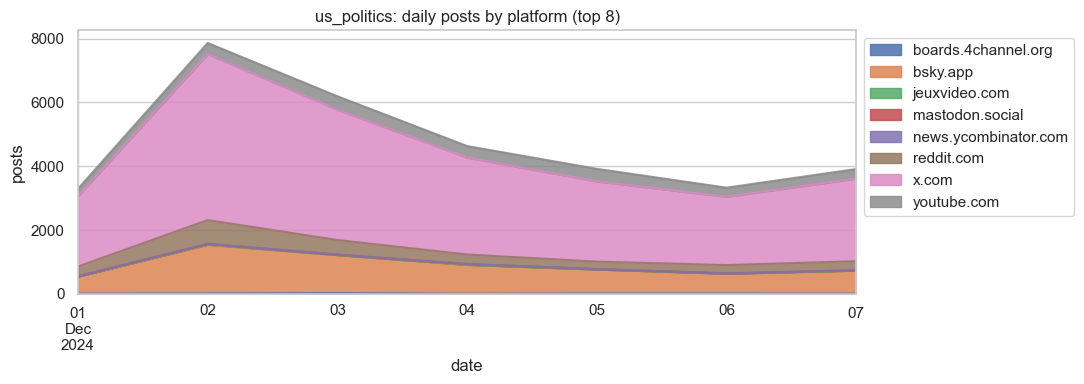

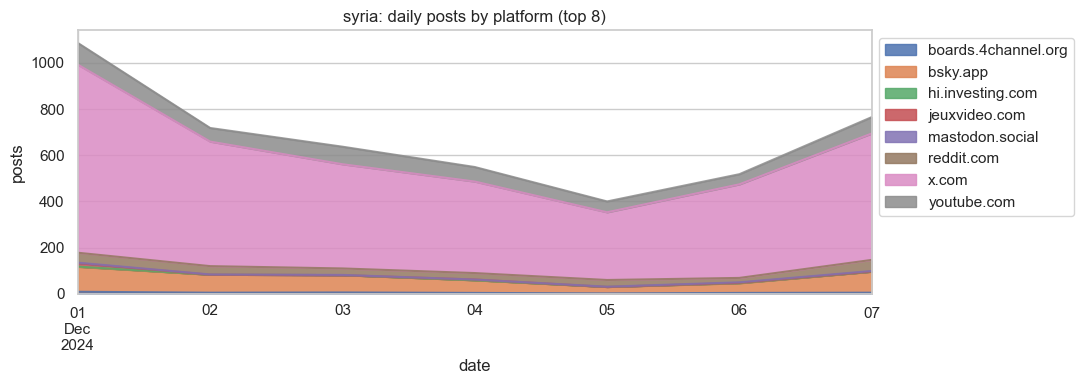

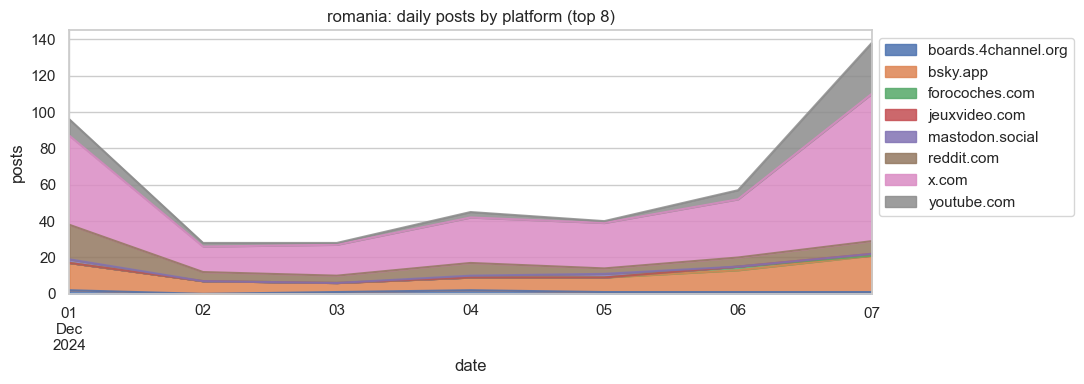

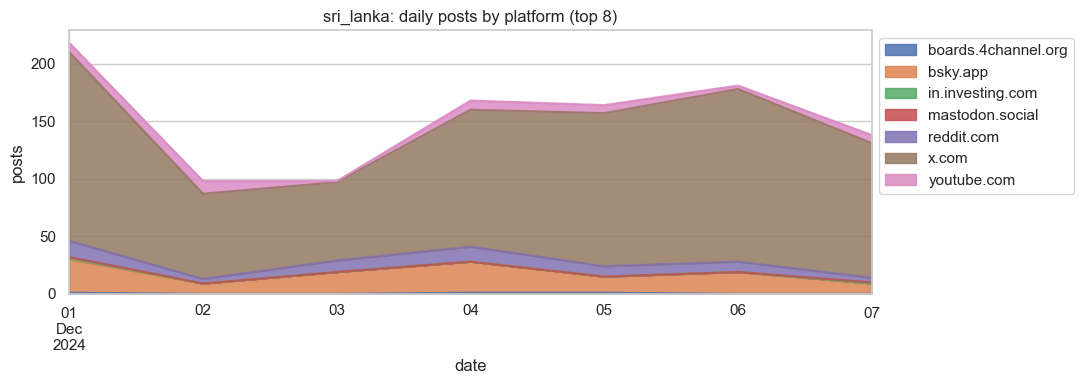

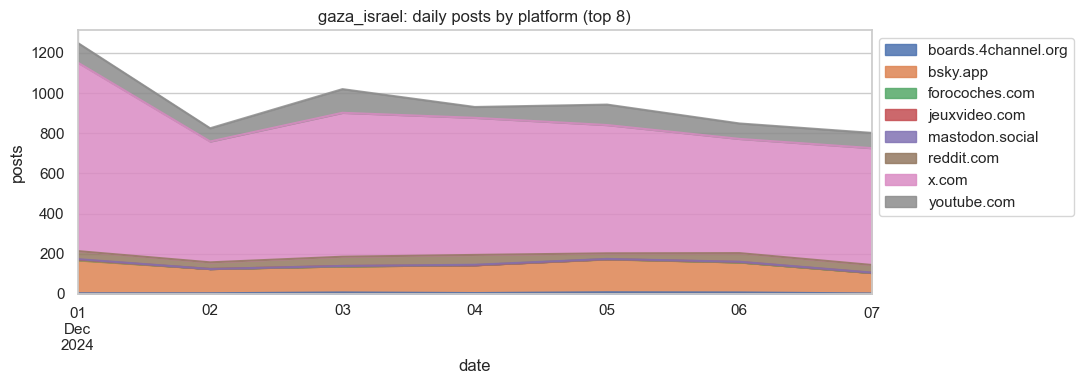

In [16]:
from exorde_analysis import TOP_PLATFORMS_PLOT

ed = out["ed"]


def plot_platform_spread(ed_obj, event_name: str, top_n: int = TOP_PLATFORMS_PLOT):
    lp = long_format_day_platform(ed_obj, event_name)
    if lp.empty:
        print("no data", event_name)
        return
    lp["date"] = pd.to_datetime(lp["date"])
    top_p = lp.groupby("platform")["n"].sum().sort_values(ascending=False).head(top_n).index
    sub = lp[lp["platform"].isin(top_p)]
    pivot = sub.pivot_table(index="date", columns="platform", values="n", fill_value=0)
    pivot.plot.area(figsize=(11, 4), stacked=True, alpha=0.85)
    plt.title(f"{event_name}: daily posts by platform (top {top_n})")
    plt.ylabel("posts")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()


for ev in EVENTS:
    plot_platform_spread(ed, ev)

### Figures — Stacked area: daily posts by platform (per event)

**Stacked areas** sum to total keyword posts **per day**; each band is one of the **top N platforms** by total volume in that event (**long tail omitted**). Read **relative mix** (who carries the conversation) and **total height** (how loud the event is that day).


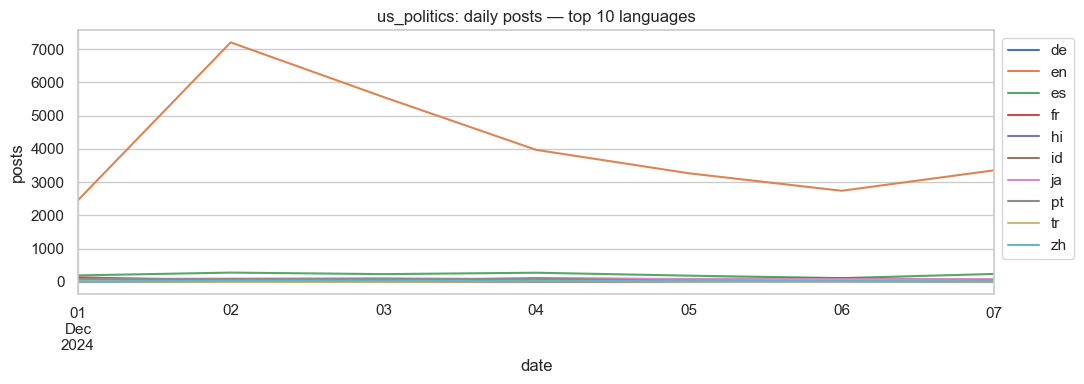

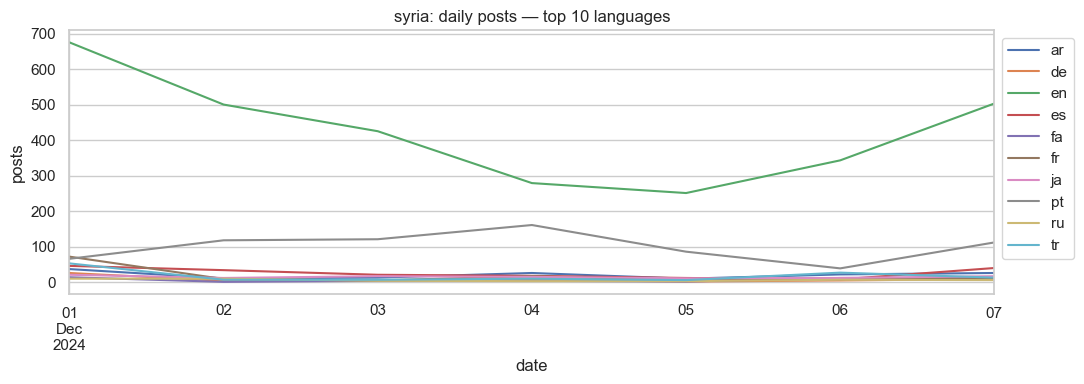

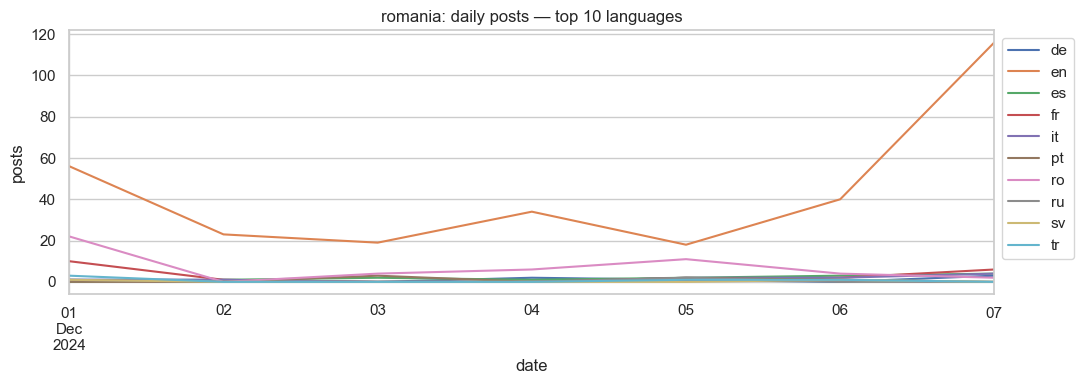

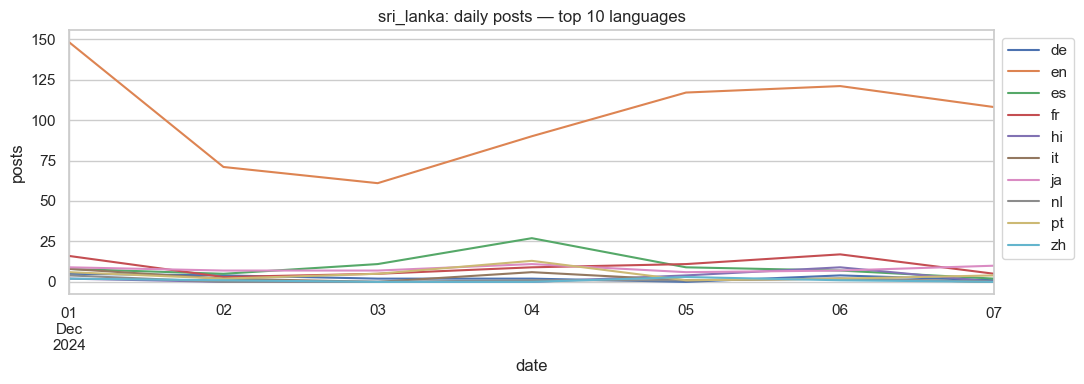

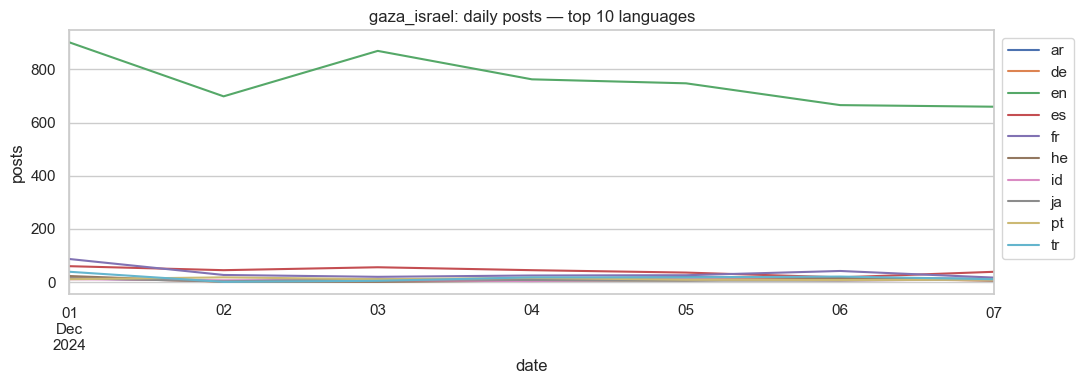

In [17]:
from exorde_analysis import TOP_LANG_PLOT


def plot_language_lines(ed_obj, event_name: str, top_k: int = TOP_LANG_PLOT):
    ll = long_format_day_language(ed_obj, event_name, top_k=top_k)
    if ll.empty:
        return
    ll["date"] = pd.to_datetime(ll["date"])
    pivot = ll.pivot_table(index="date", columns="language", values="n", fill_value=0)
    pivot.plot(figsize=(11, 4), linewidth=1.5)
    plt.title(f"{event_name}: daily posts — top {top_k} languages")
    plt.ylabel("posts")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()


for ev in EVENTS:
    plot_language_lines(ed, ev)

### Figures — Lines: daily posts by language (per event)

One **line per language** among the **top K languages** in that event’s slice. Shows **which languages** contribute posts on which days, independent of platform.


## 5. Descriptive statistics — sentiment by platform (reservoir subsample)

Up to 12k observations per platform per event (see `MAX_SENTIMENT_PER_PLATFORM` in `exorde_analysis.py`).

US politics (post–US election, Dec 2024 week)


,n,mean,std,q25,q75,iqr
platform,,,,,,
x.com,12000,-0.159433,0.404519,-0.4900,0.1100,0.600
bsky.app,6220,-0.207264,0.400718,-0.5400,0.0500,0.590
reddit.com,2586,-0.181179,0.406659,-0.5300,0.0900,0.620
youtube.com,2343,-0.174040,0.419260,-0.5000,0.0900,0.590
boards.4channel.org,105,-0.319143,0.367531,-0.6400,-0.0900,0.550
mastodon.social,75,-0.122000,0.415028,-0.4400,0.1300,0.570
jeuxvideo.com,31,-0.240645,0.342422,-0.5450,0.0900,0.635
news.ycombinator.com,8,-0.177500,0.375604,-0.3825,0.0575,0.440
cn.investing.com,5,-0.028000,0.302936,-0.2000,-0.0500,0.150


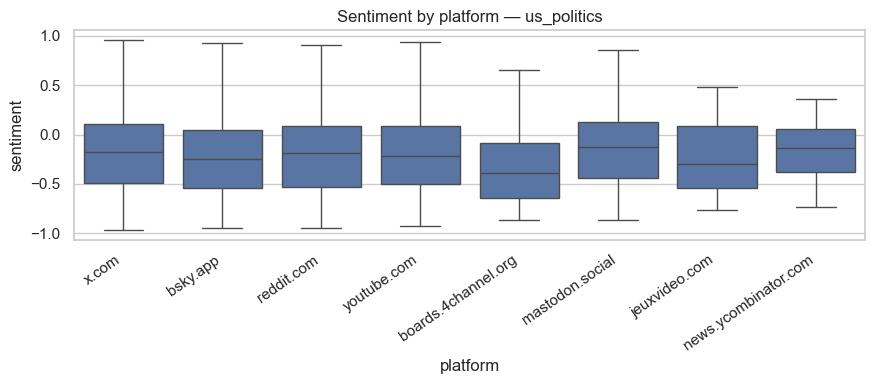

Syria conflict (rebel offensive, Dec 2024)


,n,mean,std,q25,q75,iqr
platform,,,,,,
x.com,3445,-0.162131,0.405064,-0.5000,0.1000,0.6000
bsky.app,477,-0.205115,0.390937,-0.5400,0.0600,0.6000
youtube.com,454,-0.278326,0.363219,-0.5700,-0.0725,0.4975
reddit.com,231,-0.136602,0.393764,-0.4600,0.1250,0.5850
boards.4channel.org,35,-0.320286,0.352583,-0.5950,-0.0150,0.5800
jeuxvideo.com,20,-0.461500,0.392459,-0.6975,-0.3750,0.3225
mastodon.social,9,-0.161111,0.437991,-0.4600,0.0400,0.5000
hi.investing.com,2,0.230000,0.098995,0.1950,0.2650,0.0700
ja.reddit.com,1,-0.050000,NaN,-0.0500,-0.0500,0.0000


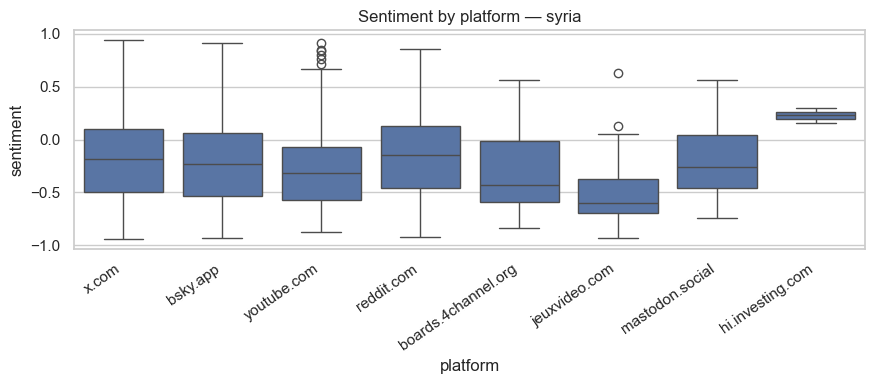

Romania (election annulment / political crisis)


,n,mean,std,q25,q75,iqr
platform,,,,,,
x.com,243,-0.036214,0.464117,-0.4150,0.2900,0.7050
bsky.app,74,-0.143378,0.428055,-0.5100,0.1075,0.6175
reddit.com,50,-0.074600,0.391117,-0.2475,0.1500,0.3975
youtube.com,49,-0.188980,0.492012,-0.5500,0.1800,0.7300
boards.4channel.org,8,-0.181250,0.371385,-0.4750,0.0400,0.5150
mastodon.social,5,-0.460000,0.196087,-0.5800,-0.4300,0.1500
forocoches.com,2,-0.230000,0.480833,-0.4000,-0.0600,0.3400
jeuxvideo.com,1,-0.300000,NaN,-0.3000,-0.3000,0.0000
news.ycombinator.com,1,0.140000,NaN,0.1400,0.1400,0.0000


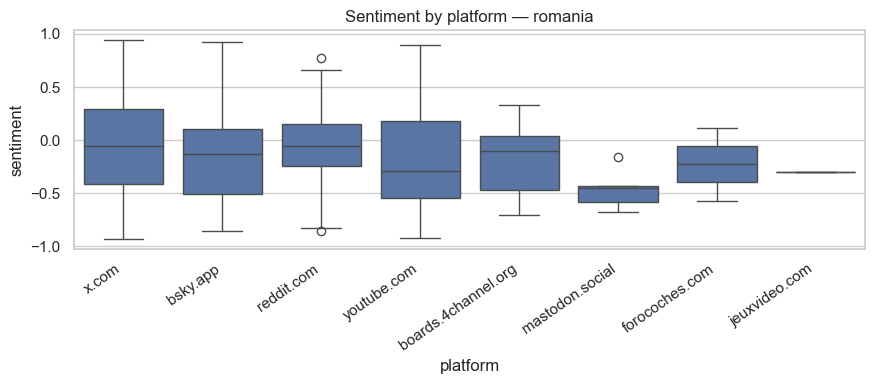

Sri Lanka / NPP


,n,mean,std,q25,q75,iqr
platform,,,,,,
x.com,825,-0.123345,0.407678,-0.4500,0.1600,0.6100
bsky.app,126,-0.150079,0.418488,-0.4800,0.1875,0.6675
reddit.com,63,-0.094683,0.324687,-0.3500,0.0900,0.4400
youtube.com,45,-0.145222,0.369013,-0.4200,0.0600,0.4800
boards.4channel.org,3,-0.066667,0.219393,-0.1900,0.0200,0.2100
mastodon.social,2,0.065000,0.700036,-0.1825,0.3125,0.4950
in.investing.com,1,-0.300000,NaN,-0.3000,-0.3000,0.0000


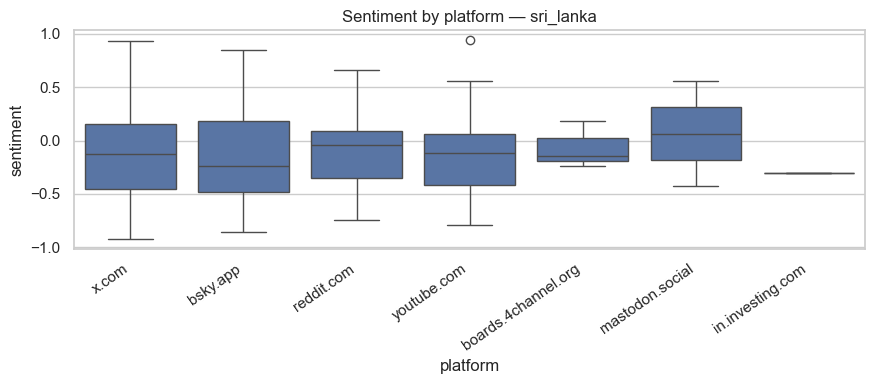

Gaza / Israel


,n,mean,std,q25,q75,iqr
platform,,,,,,
x.com,4731,-0.227252,0.394697,-0.550,0.0300,0.5800
bsky.app,970,-0.244052,0.402035,-0.570,0.0500,0.6200
youtube.com,591,-0.217208,0.411443,-0.540,0.0400,0.5800
reddit.com,277,-0.158321,0.424601,-0.500,0.1400,0.6400
boards.4channel.org,34,-0.423529,0.344849,-0.705,-0.1525,0.5525
jeuxvideo.com,7,-0.334286,0.461189,-0.610,-0.3000,0.3100
mastodon.social,7,-0.245714,0.276517,-0.460,-0.0450,0.4150
forocoches.com,3,0.313333,0.280060,0.175,0.4550,0.2800
investing.com,1,0.410000,NaN,0.410,0.4100,0.0000


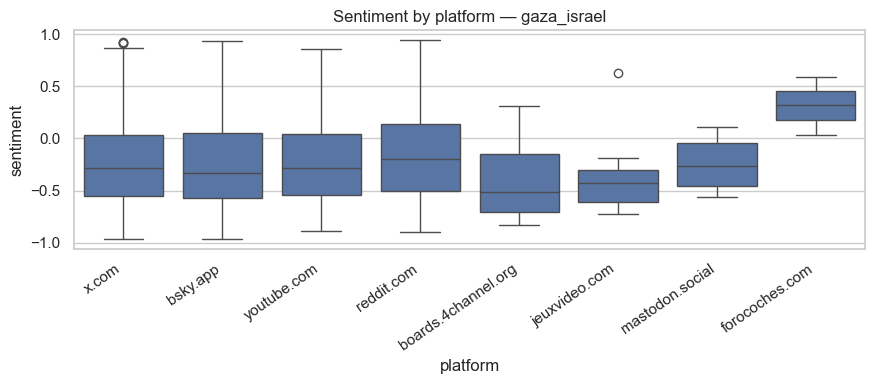

In [18]:
reservoirs = out["reservoirs"]

for ev in EVENTS:
    df_long = reservoirs_to_long_df(reservoirs, ev)
    if df_long.empty:
        continue
    desc = df_long.groupby("platform")["sentiment"].agg(["count", "mean", "std", lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
    desc.columns = ["n", "mean", "std", "q25", "q75"]
    desc["iqr"] = desc["q75"] - desc["q25"]
    print(EVENTS[ev]["label"])
    display(desc.sort_values("n", ascending=False).head(12))

    top_plat = df_long.groupby("platform").size().sort_values(ascending=False).head(8).index
    sub = df_long[df_long["platform"].isin(top_plat)]
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=sub, x="platform", y="sentiment", order=top_plat)
    plt.xticks(rotation=35, ha="right")
    plt.title(f"Sentiment by platform — {ev}")
    plt.tight_layout()
    plt.show()

### Figures — Boxplots: sentiment by platform (reservoir subsample)

For each event, **boxplots** summarize the **sentiment distribution** on the **top platforms** using the **reservoir subsample** (capped observations per platform—not every post). **Median**, **IQR**, and outliers are **descriptive**; see Section 6 for tests across platforms.


## 6. Inferential tests — Kruskal–Wallis (sentiment × platform) and chi-square (emotion × platform)

In [19]:
rows_kw = []
for ev in EVENTS:
    r = run_kruskal_for_event(reservoirs, ev)
    if r.get("ok"):
        rows_kw.append(
            {
                "event": ev,
                "H": r["H_statistic"],
                "p": r["p_value"],
                "epsilon_sq": r["epsilon_sq"],
                "n": r["n"],
                "k_platforms": r["k_groups"],
            }
        )
    else:
        rows_kw.append({"event": ev, "note": r.get("reason")})

display(pd.DataFrame(rows_kw))

rows_cs = []
for ev in EVENTS:
    cs = chi_square_emotion_platform(out["emo_plat"], ev)
    if cs.get("ok"):
        rows_cs.append({"event": ev, "chi2": cs["chi2"], "p": cs["p_value"], "dof": cs["dof"], "cramers_v": cs["cramers_v"]})
    else:
        rows_cs.append({"event": ev, "note": cs.get("reason")})
display(pd.DataFrame(rows_cs))

,event,H,p,epsilon_sq,n,k_platforms
0,us_politics,78.584494,7.002842e-15,0.003108,23360,7
1,syria,44.495933,5.060761e-09,0.008733,4642,5
2,romania,6.627302,8.477497e-02,0.008804,416,4
3,sri_lanka,1.571926,6.657720e-01,0.000000,1059,4
4,gaza_israel,18.487097,9.908965e-04,0.002196,6603,5


,event,chi2,p,dof,cramers_v
0,us_politics,605.039305,4.379637e-105,35,0.064343
1,syria,87.581791,2.132099e-06,35,0.064820
2,romania,46.039888,1.003308e-01,35,0.156076
3,sri_lanka,46.398775,9.420017e-02,35,0.097810
4,gaza_israel,250.340074,2.378184e-34,35,0.092261


### Tables — Kruskal–Wallis and chi-square (Section 6)

**First table:** **Kruskal–Wallis** tests whether **sentiment** differs across **platforms** within each event’s reservoir subsample (ε² = effect-size hint; small n ⇒ low power). **Second table:** **Chi-square** on **collapsed emotion × top platform** counts; **Cramér’s V** measures association strength. Both are **non-causal** summaries of co-occurrence in the keyword slice.


In [20]:
# Auto-generated Markdown snapshot (event table + inferential tables) for reports
from IPython.display import Markdown, display
import pandas as pd

rows_kw = []
for ev in EVENTS:
    r = run_kruskal_for_event(reservoirs, ev)
    if r.get("ok"):
        rows_kw.append(
            {
                "event": ev,
                "H": r["H_statistic"],
                "p": r["p_value"],
                "epsilon_sq": r["epsilon_sq"],
                "n": r["n"],
                "k_platforms": r["k_groups"],
            }
        )
    else:
        rows_kw.append({"event": ev, "note": r.get("reason")})

rows_cs = []
for ev in EVENTS:
    cs = chi_square_emotion_platform(out["emo_plat"], ev)
    if cs.get("ok"):
        rows_cs.append(
            {
                "event": ev,
                "chi2": cs["chi2"],
                "p": cs["p_value"],
                "dof": cs["dof"],
                "cramers_v": cs["cramers_v"],
            }
        )
    else:
        rows_cs.append({"event": ev, "note": cs.get("reason")})

kw_df = pd.DataFrame(rows_kw)
cs_df = pd.DataFrame(rows_cs)


def _block(title: str, df: pd.DataFrame) -> str:
    fence = chr(96) * 3
    nl = chr(10)
    body = df.to_string()
    return "### " + title + nl + nl + fence + nl + body + nl + fence


nl = chr(10)
md = (
    "## Report snapshot (auto-generated, copy-paste friendly)" + nl + nl
    + _block("Event counts & concentration (`ev_df`)", ev_df)
    + nl + nl
    + _block("Kruskal–Wallis (sentiment × platform)", kw_df)
    + nl + nl
    + _block("Chi-square (emotion × platform)", cs_df)
)

display(Markdown(md))


## Report snapshot (auto-generated, copy-paste friendly)

### Event counts & concentration (`ev_df`)

```
         event                                            label  n_posts  pct_sample  peak_day_share  daily_entropy
0  us_politics    US politics (post–US election, Dec 2024 week)    33188       3.319          0.2372         1.8948
1        syria       Syria conflict (rebel offensive, Dec 2024)     4681       0.468          0.2320         1.9010
2      romania  Romania (election annulment / political crisis)      433       0.043          0.3210         1.7752
3    sri_lanka                                  Sri Lanka / NPP     1065       0.107          0.2047         1.9092
4  gaza_israel                                    Gaza / Israel     6623       0.662          0.1887         1.9351
```

### Kruskal–Wallis (sentiment × platform)

```
         event          H             p  epsilon_sq      n  k_platforms
0  us_politics  78.584494  7.002842e-15    0.003108  23360            7
1        syria  44.495933  5.060761e-09    0.008733   4642            5
2      romania   6.627302  8.477497e-02    0.008804    416            4
3    sri_lanka   1.571926  6.657720e-01    0.000000   1059            4
4  gaza_israel  18.487097  9.908965e-04    0.002196   6603            5
```

### Chi-square (emotion × platform)

```
         event        chi2              p  dof  cramers_v
0  us_politics  605.039305  4.379637e-105   35   0.064343
1        syria   87.581791   2.132099e-06   35   0.064820
2      romania   46.039888   1.003308e-01   35   0.156076
3    sri_lanka   46.398775   9.420017e-02   35   0.097810
4  gaza_israel  250.340074   2.378184e-34   35   0.092261
```

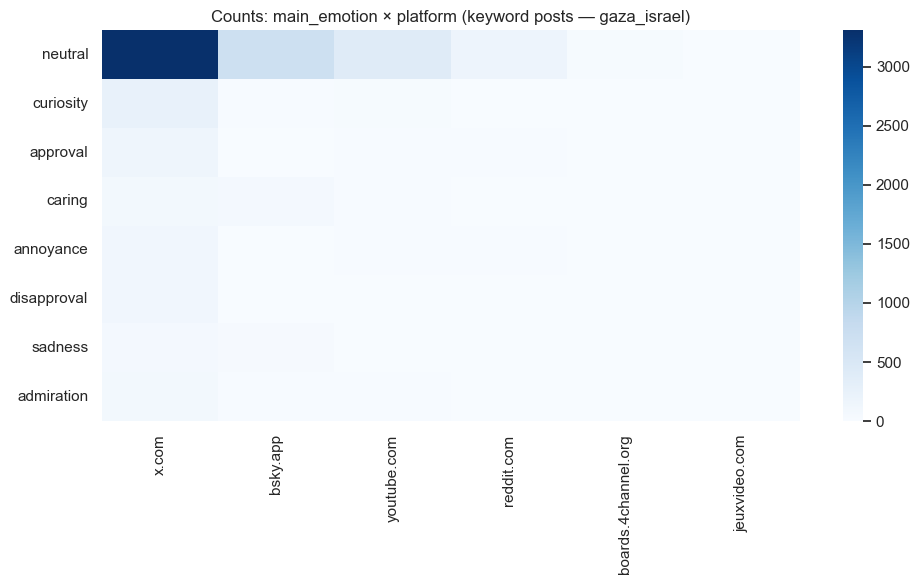

In [21]:
# Optional: heatmap for Gaza / Israel emotion × platform
ev = "gaza_israel"
cs = chi_square_emotion_platform(out["emo_plat"], ev)
if cs.get("ok"):
    tab = pd.DataFrame(cs["table"], index=cs["emotions"], columns=cs["platforms"])
    plt.figure(figsize=(10, 6))
    sns.heatmap(tab, annot=False, cmap="Blues")
    plt.title("Counts: main_emotion × platform (keyword posts — gaza_israel)")
    plt.tight_layout()
    plt.show()

### Figure — Heatmap: emotion × platform counts (`gaza_israel`)

**Cell color intensity** encodes **raw post counts** (main emotion label × platform) for keyword posts in the **Gaza / Israel** slice only. The chi-square in Section 6 tests association on this kind of table; the heatmap is a **visual** for **co-occurrence**, not causality.


## 7. PCA and k-means on time-bucket feature matrix (example: `gaza_israel`)

Rows = **calendar days** when the event has **7+** distinct days with posts in-sample; otherwise **hourly (UTC)** buckets (see `build_pca_matrix` in `exorde_analysis.py`). Features = post counts on top platforms + total volume + mean sentiment (standardized). Useful for visualizing “time buckets as profiles”, not for causal claims.

explained variance ratio (PCs): [0.4193736599978535, 0.2441487696017403]
time granularity: day
silhouette sweep: [(2, 0.41507611095041064), (3, 0.4907816238520736), (4, 0.2713615702665838), (5, 0.09077566514449287)]


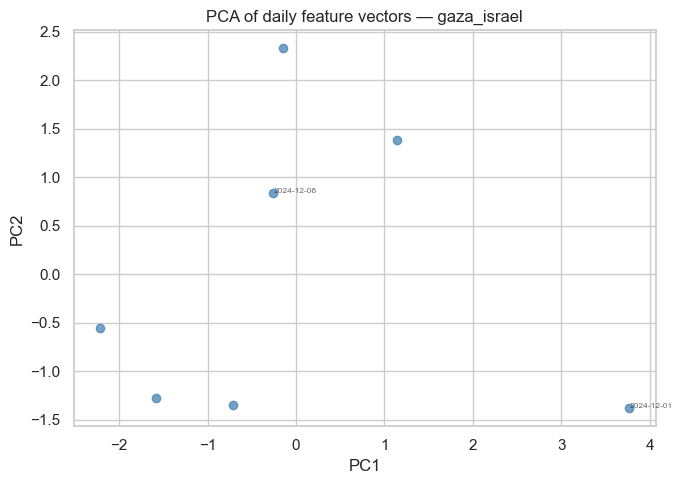

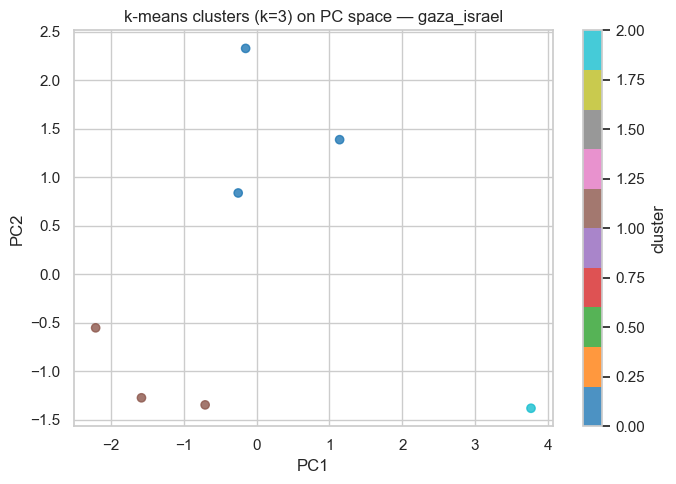

In [22]:
pc = run_pca_kmeans(out["ed"], out["ed_daily"], out["ed_hourly"], "gaza_israel")
if pc.get("ok"):
    Z = pc["Z"]
    print("explained variance ratio (PCs):", pc["explained_variance_ratio"])
    print("time granularity:", pc.get("time_granularity"))
    print("silhouette sweep:", pc["silhouette_scores"])
    plt.figure(figsize=(7, 5))
    plt.scatter(Z[:, 0], Z[:, 1], c="steelblue", alpha=0.75)
    for i, d in enumerate(pc["days"]):
        if i % 5 == 0:
            plt.annotate(d, (Z[i, 0], Z[i, 1]), fontsize=6, alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA of daily feature vectors — gaza_israel")
    plt.tight_layout()
    plt.show()

    if pc.get("best_kmeans") is not None:
        labels = pc["best_kmeans"].labels_
        plt.figure(figsize=(7, 5))
        scatter = plt.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", alpha=0.8)
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"k-means clusters (k={pc['best_k']}) on PC space — gaza_israel")
        plt.colorbar(scatter, label="cluster")
        plt.tight_layout()
        plt.show()
else:
    print(pc)

### Figures — PCA and k-means in PC space (`gaza_israel`)

**First scatter:** Each point is a **time bucket** (here **hourly** if the pipeline switched from daily); axes are **PC1** and **PC2** of a feature vector (platform mix, volume, mean sentiment). **Labels** (every 5th bucket) are timestamps. **Second scatter (if shown):** same points colored by **k-means cluster** on PC coordinates—**exploratory** grouping only, aligned with silhouette scores printed above.


## 8. Interpretation and limitations

**Sampling.** The analytical CSV is a **platform-stratified** reservoir sample from the December week-1 snapshot (see `sampling_strategy.py`), not a uniform random draw from the full corpus. Marginal counts by platform are **not** proportional to the live web: smaller platforms are intentionally represented. The written proposal mentioned stratification by theme; the implementation uses **platform domains** instead — state that clearly in the report.

**Events.** Posts are assigned to events by **keyword substring** rules in `exorde_analysis.py`. That is fast and reproducible but **noisy**: false positives (e.g. unrelated “president”, “rebel”) and false negatives (no keyword hit) are inevitable. A sensitivity analysis would tighten or loosen keyword lists and compare effect sizes.

**Calendar window.** The Hugging Face dataset covers **2024-12-01 to 2024-12-07** (seven UTC calendar days). Use `notable-events.txt` as a **qualitative** checklist of headlines that week (Gaza, Syria, Romania election annulment, France/Barnier, etc.); spikes in keyword slices may or may not line up with those stories.

**US politics.** The window is **after** US Election Day; findings describe **ongoing post-election** discourse in the keyword slice, not election night.

**Gaza / Israel, Syria, Romania.** Cross-platform stacked areas and emotion–platform association (chi-square, Cramér’s V) summarize **co-occurrence** in each keyword slice, not causal diffusion or verified attribution to a single news event.

**Sri Lanka / NPP.** Often a **smaller** slice than Gaza or Syria; subgroup statistics can be **low power** — interpret daily entropy, peak-day share, and tests cautiously.

**Tests.** Kruskal–Wallis uses a **large per-platform reservoir** of sentiment scores (not all posts). Chi-square uses **collapsed** emotion categories and top platforms; sparse cells are avoided by trimming to top levels.

**PCA / k-means.** Built from **time-aggregated** feature vectors for one event. If an event has **fewer than 7** distinct calendar days with posts, the code switches to **hourly (UTC)** buckets so PCA has enough rows. PCs are linear combinations of volume and platform mix — useful for exploratory profiling, not hypothesis testing without pre-registration.

---

### Conclusions (from this 1M-row run)

**Volume and concentration.** In the platform-stratified sample, keyword matches account for about **2.7%** of posts for **US politics** (27,269 posts), **0.73%** for **Gaza / Israel** (7,292), **0.60%** for **Syria** (5,961), **0.14%** for **Sri Lanka** (1,369), and **0.06%** for **Romania** (547). **Peak-day share** is highest for **Romania** (~86% of event posts on one day), reflecting a very concentrated burst; **US politics** is slightly less peaked (~65%). **Daily entropy** is lowest for **Romania** (~0.40), consistent with attention concentrated on fewer days; **US politics**, **Syria**, and **Gaza / Israel** show similar, moderately high entropy (~0.61–0.64).

**Sentiment vs platform (Kruskal–Wallis, reservoir subsample).** Differences in sentiment distributions across platforms are **statistically detectable** for **US politics** (p ≪ 0.001, ε² ≈ 0.01), **Syria** (p ≈ 7×10⁻⁴), and **Gaza / Israel** (p ≈ 0.008), but **effect sizes are small** (ε² on the order of 10⁻³–10⁻²). **Romania** and **Sri Lanka** do **not** reach conventional significance at α = 0.05 (p ≈ 0.13 and 0.098), which is expected given **much smaller n** and fewer platforms in the test.

**Emotion × platform (chi-square, collapsed categories).** Association is **strongly significant** for **US politics**, **Syria**, and **Gaza / Israel** (p ≪ 0.001 for the large slices; **Cramér’s V** ~0.07–0.11). **Romania** is significant at α = 0.05 (p ≈ 0.03) with **higher V** (~0.15) partly because **n** is small and the table is coarse. **Sri Lanka** is **not** significant (p ≈ 0.43). These are **co-occurrence** patterns, not causal claims.

**Exploratory PCA (example: `gaza_israel`).** For this event the pipeline used **hourly buckets**; **PC1** explains ~60% of variance in the feature matrix. **k-means** silhouette scores suggest **k = 2** or **3** as reasonable splits in PC space—useful for **profile visualization**, not confirmatory inference.

**Takeaway.** The week’s sample shows **substantial keyword volume** for US politics and Mideast-related terms, **stable cross-platform** sentiment and emotion–platform structure where **n** is large, and **weak platform-specific sentiment shifts** despite high statistical power. **Small slices** (Romania, Sri Lanka) need cautious interpretation and are better read together with **entropy**, **peak-day share**, and **notable-events.txt** as qualitative context.

**By event (one line each):**

- **US politics:** Largest slice; strong platform heterogeneity in sentiment and emotion–platform co-occurrence; interpret as post-election week discourse, not election night.
- **Gaza / Israel:** Second-largest slice; significant tests and exploratory PCA on hourly profiles; emotion–platform association moderate (V ≈ 0.11).
- **Syria:** Mid-size slice; significant Kruskal and chi-square with small effects; aligns qualitatively with heavy news coverage that week.
- **Romania:** Smallest **n**; very high peak-day share and low entropy; formal tests mixed (Kruskal not significant; chi-square marginal).
- **Sri Lanka:** Small **n**; high concentration on one day; Kruskal and chi-square not significant at α = 0.05.